In [8]:
import torch
from torch import nn # nn contains all of PyTorch's buidling blocks for neural networks
import matplotlib.pyplot as plt


In [5]:
what_were_covering = {
    1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference) ",
    5: "saving and loading model",
    6: "putting it all together"
}

what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference) ',
 5: 'saving and loading model',
 6: 'putting it all together'}

# 1. data (preparing and loading)

Data can be almost anything.. in machine learning.

* excel speadsheet
* images of any king
* videos
* Audio like songs or podcast
* DNA
* Text


Machine learning is a game of two parts

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation


To showcase this, let's create some known data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known **parameters**.


In [10]:
# create known parameters
weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02

# X том үсгээр эхэлсэн байгаа. Энэ нь tensor and matrix илэрхийлдэг
# y жижиг үсгээр эхэлсэг байгаа. энэ нь vector илэрхийлдэг
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [11]:
len(X), len(y)

(50, 50)

# Splitting data into trainig and testing sets


In [18]:
# create a train/test split
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_yest = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_yest)

(40, 40, 10, 10)

In [26]:
def plot_predictions(train_data=X_train,train_labels=y_train,test_data = X_test, test_labels = y_yest, predictions=None):
    # Plots training data, test data and compares predictions
    plt.figure(figsize=(10, 7))

    # plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label='Training data')

    # plot test data in green
    plt.scatter(test_data, test_labels, c="r", s=4, label='Testing data')

    # are there predictions?
    if predictions is not None:
        # plot  the predictions if they exist
        plt.scatter(test_data, predictions, c="g", s=4, label='Predictions')

    # show the legend
    plt.legend(prop={"size": 14})
    

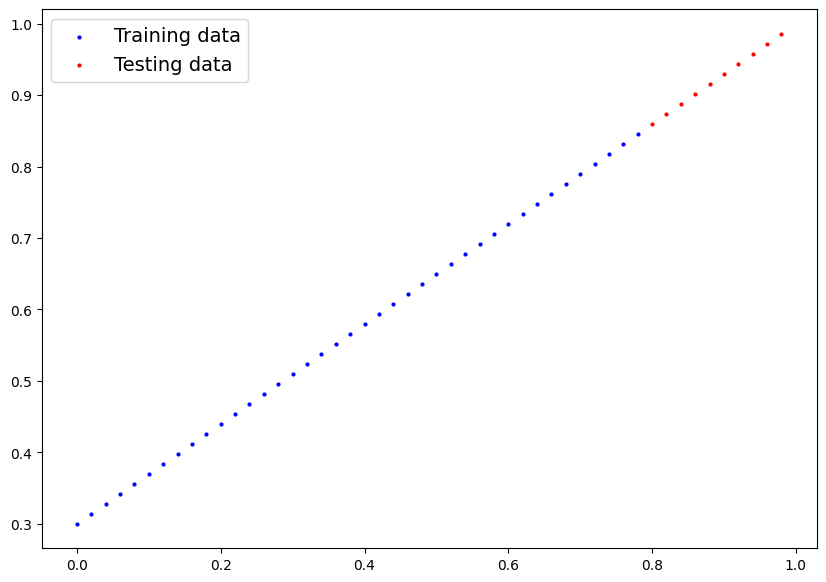

In [27]:
plot_predictions()

# build model

In [28]:
# create linear regression model class

# nn.Module -> almost everything in PyTorch inherits from nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    # Forward method to define the computation in the model
    # x is input data
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias # this is the linear regression formula


In [ ]:
torch.manual_seed(42) # remove this code and then execute it 
torch.randn(1)

tensor([0.3367])

# PyTorch model building essentials

* torch.nn - contains all of the buidligs for computational graphs(another word for neural netwrok can be considered a computtational graph)
* torch.nn.Parameter -  What parameters should our model try an learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module _ The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this where the optimizers in PyTorch live, they wll help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

In [ ]:
# checking the contents of our PyTirch model

# checking the contents of our PyTirch model

Now we've created a model, let's see what's inside...

So we can check our model parameters or what's inside our model using. parameters().

In [34]:
# creare a random seed
torch.manual_seed(42)

# create an instance of the model (thsi is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [36]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# Making prediction using `torch.inference_mode()`

To check our model's predictivce power, let's see how ell it predicts `y_test` based on `X_test`

when we pass data through our mode, it's going to run it through the `forward()` method.

In [40]:
X_test, y_yest

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [46]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [45]:
# make predictions wiht model
with torch.inference_mode():
    y_preds = model_0(X_test)

# you can also do something similar with torch.no_grad(), however, torch.inference_mode() is preferred
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

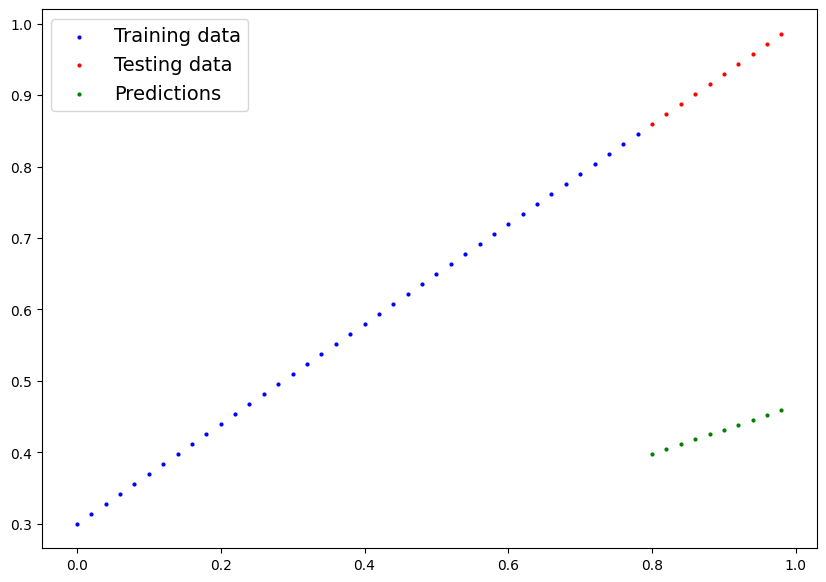

In [42]:
plot_predictions(predictions=y_preds)

# Train model

The whole idea of training is for a model to move from somve unknown parameters(thses may be random) to some known parameters

Or in other words from a poor representation of the data to a better representation of the data

One way to measure how poor or how wrong your models predictions are is to usea loss function.


* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function

Things we need to train:

*  **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better
*  **Optimizer:** Takes into account the loss of a model and adjust the model's parameters(e.g weight & bias in our case ) to improve the loss function.

and specifically for PyTorch, we need:
* A training loop
* A testing loop

In [ ]:
# check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# Loss function

**Mean absolute erro(MAE) = Repeat fot all and take the mean

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-mae-loss-annotated.png" alt="Alt text" width="700" height="400">


In [ ]:
# setup a loss function
loss_fn = nn.L1Loss()

# setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # lr=learning rate = possible the most important hyperparameter you can set

In [50]:
loss_fn

L1Loss()

# Building a training loop (and a testing loop) in PyTorch
a couple of things we need in a traininn loop:

0. Loop through the data
1. Forward pass (thi involves data moving through our model's `forward()` function ) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labes)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model woth repsect to the loss
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [ ]:
model_0.eval().parameters
with torch.inference_mode():
    list(model_0.parameters())

In [56]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# An epoch is one loop through the data...
epochs = 1

# 0. Loop through the data
for epoch in range(epochs):
    # set the model to training mode
    model_0.train()

SyntaxError: invalid syntax (458094364.py, line 5)

In [ ]:
6:15